In [24]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv("train.csv")

In [26]:
df.head()
# print(pr)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [28]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


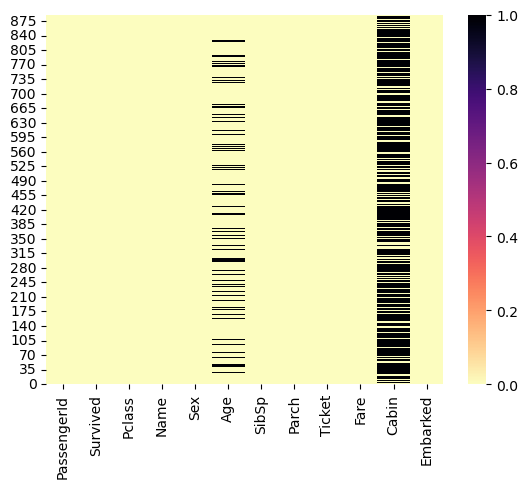

In [29]:
sb.heatmap(df.isnull(), cmap = 'magma_r')
# sb.heatmap(df.isnull(), cmap=sb.color_palette("magma", as_cmap=True).reversed())
plt.gca().invert_yaxis() # flips the y-axis plt.show()

In [30]:
cabin_list = [ 'A', 'B', 'C', 'D', 'E', 'F', 'T', 'G', 'Unknown' ]

In [31]:
def search_substring(big_string, substring_list):
    for substring in substring_list:
        if substring in big_string:
            return substring
    return substring_list[-1]   # return last element if none found

In [41]:
def get_title(string): # function get_title and it has a parameter string, that string contains passenger name
    import re #regular expression module is used for pattern matching or also known as regex library
    reg = re.compile(r'Mr|Don|Major|Capt|Jonkheer|Rev|Col|Dr|Mrs|Countess|Dona|Mme|Ms|Miss|Mile|Mater', re.IGNORECASE) #it ignore upper or lower, 
    # it provide it original form
    results = reg.search(string)
    if results != None:
        return (results.group().lower()) #lower() it will take it as smaller
    else:
        return(str(np.nan))

In [33]:
get_title("Braund, Mr. Owen Harris") # regex will take all value and match it with any titles

'mr'

In [34]:
# dictionary to map to generate the new feature vector
title_dictionary = {
"capt":"Officer",
"col":"Officer",
"major":"Officer",
"dr":"Officer",
"jonkheer":"Royalty",
"rev":"Officer",
"countess":"Royalty",
"dona":"Royalty",
"lady":"Royalty",
"don":"Royalty",
"mr":"Mr",
"mme":"Mrs",
"ms":"Mrs",
"mrs":"Mrs",
"miss":"Miss",
"mlle":"Miss",
"master":"Master",
"nan":"Mr"
}

In [36]:
df['Deck'] = df['Cabin'].map(lambda x: search_substring(str(x), cabin_list))

In [37]:
df.drop('Cabin', axis = 1, inplace = True)

In [42]:
df['Title'] = df['Name'].apply(get_title)

In [43]:
df['Title'] = df['Title'].map(title_dictionary)